In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import re
from transformers import pipeline
import time

# Start timing
start_time = time.time()

c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2: Load test data
# Load test data
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"
df_test = pd.read_csv(test_path)
print(f"Loaded test data with {len(df_test)} samples.")

# Create additional sentiment features
df_test['emotional_intensity'] = df_test['VADER_Positive'] + df_test['VADER_Negative']
df_test['sentiment_direction'] = df_test['TextBlob_Polarity'] * df_test['VADER_Compound']
df_test['sentiment_strength'] = abs(df_test['TextBlob_Polarity']) + abs(df_test['VADER_Compound'])
print("Created additional sentiment features.")

Loaded test data with 860 samples.
Created additional sentiment features.


In [3]:
# Cell 3: Define emotion mappings
# Define mappings for both models
mapping1 = {
    'joy': 'happiness',
    'sadness': 'sadness',  
    'anger': 'anger',
    'fear': 'fear',
    'surprise': 'surprise',
    'disgust': 'disgust',
    'neutral': 'neutral'
}

mapping2 = {
    'admiration': 'happiness', 'amusement': 'happiness', 'approval': 'happiness',
    'caring': 'happiness', 'desire': 'happiness', 'excitement': 'happiness',
    'gratitude': 'happiness', 'joy': 'happiness', 'love': 'happiness',
    'optimism': 'happiness', 'pride': 'happiness', 'relief': 'happiness',
    
    'sadness': 'sadness', 'disappointment': 'sadness', 
    'grief': 'sadness', 'remorse': 'sadness',
    
    'anger': 'anger', 'annoyance': 'anger', 'disapproval': 'anger',
    
    'fear': 'fear', 'nervousness': 'fear',
    
    'surprise': 'surprise', 'realization': 'surprise', 'confusion': 'surprise',
    
    'disgust': 'disgust',
    
    'neutral': 'neutral', 'curiosity': 'neutral', 'embarrassment': 'neutral'
}

In [4]:
# Cell 4: Load models and run predictions
# Load models
print("Loading first model (distilroberta-base)...")
model1 = pipeline("text-classification", 
                 model="j-hartmann/emotion-english-distilroberta-base",
                 top_k=None)

print("Loading second model (roberta-base-go_emotions)...")
model2 = pipeline("text-classification", 
                 model="SamLowe/roberta-base-go_emotions",
                 top_k=None)

# Run predictions in batches
batch_size = 16
model1_predictions = []
model1_scores = []
model2_predictions = []
model2_scores = []

print(f"Running predictions on {len(df_test)} samples with batch size {batch_size}...")
for i in range(0, len(df_test), batch_size):
    if i % 100 == 0 and i > 0:
        print(f"Processed {i} samples...")
        
    batch_texts = df_test['text'][i:i+batch_size].tolist()
    
    # Model 1 predictions
    batch_results1 = model1(batch_texts)
    for result in batch_results1:
        top_emotion = max(result, key=lambda x: x['score'])
        predicted_raw = top_emotion['label']
        predicted_mapped = mapping1.get(predicted_raw, predicted_raw)
        model1_predictions.append(predicted_mapped)
        model1_scores.append({r['label']: r['score'] for r in result})
    
    # Model 2 predictions
    batch_results2 = model2(batch_texts)
    for result in batch_results2:
        top_emotion = max(result, key=lambda x: x['score'])
        predicted_raw = top_emotion['label']
        predicted_mapped = mapping2.get(predicted_raw, predicted_raw)
        model2_predictions.append(predicted_mapped)
        model2_scores.append({r['label']: r['score'] for r in result})

# Add predictions to dataframe
df_test['model1_prediction'] = model1_predictions
df_test['model2_prediction'] = model2_predictions

Loading first model (distilroberta-base)...


Device set to use cpu


Loading second model (roberta-base-go_emotions)...


Device set to use cpu


Running predictions on 860 samples with batch size 16...
Processed 400 samples...
Processed 800 samples...


In [5]:
# Cell 5: Extract emotion keywords
# Define keyword lists for each emotion
happiness_words = ['amazing', 'great', 'excited', 'love', 'happy', 'best', 'adventure', 
                  'fierce', 'top', 'model', 'competition', 'vengeance', 'chance', 
                  'cycle', 'season', 'prepared', 'expect']
sadness_words = ['sad', 'sorry', 'miss', 'lost', 'alone', 'lonely', 'grief']
anger_words = ['angry', 'mad', 'frustrat', 'hate', 'annoying', 'piss', 'fuck', 'shit', 'fake']
fear_words = ['afraid', 'scared', 'fear', 'terrif', 'stress', 'worried', 'anxiety']
surprise_words = ['wow', 'surprise', 'shocking', 'unexpected', 'crazy', 'twist', 'adventure']

# Count emotion keywords in each text
print("Extracting emotion keywords from text...")
df_test['happiness_words'] = df_test['text'].apply(
    lambda x: sum(1 for word in re.findall(r'\w+', x.lower()) if word in happiness_words)
)
df_test['sadness_words'] = df_test['text'].apply(
    lambda x: sum(1 for word in re.findall(r'\w+', x.lower()) if word in sadness_words)
)
df_test['anger_words'] = df_test['text'].apply(
    lambda x: sum(1 for word in re.findall(r'\w+', x.lower()) if word in anger_words)
)
df_test['fear_words'] = df_test['text'].apply(
    lambda x: sum(1 for word in re.findall(r'\w+', x.lower()) if word in fear_words)
)
df_test['surprise_words'] = df_test['text'].apply(
    lambda x: sum(1 for word in re.findall(r'\w+', x.lower()) if word in surprise_words)
)

Extracting emotion keywords from text...


In [6]:
# Cell 6: Define ensemble prediction function
def ensemble_prediction(row):
    """Apply ensemble rules to combine predictions"""
    # If both models agree, trust them more
    if row['model1_prediction'] == row['model2_prediction']:
        return row['model1_prediction']
    
    # Strong sentiment rules for happiness
    if (row['TextBlob_Polarity'] > 0.15 and row['VADER_Compound'] > 0.3) or row['VADER_Positive'] > 0.3:
        return 'happiness'
    
    # For Asia's Next Top Model dataset - common happiness contexts
    if 'model' in row['text'].lower() and row['model1_prediction'] != 'fear' and row['model2_prediction'] != 'fear':
        return 'happiness'
    
    # Strong negative sentiment for sadness/anger
    if row['VADER_Compound'] < -0.3:
        if row['sadness_words'] > row['anger_words']:
            return 'sadness'
        else:
            return 'anger'
    
    # Keyword-based rules
    emotion_word_counts = {
        'happiness': row['happiness_words'],
        'sadness': row['sadness_words'],
        'anger': row['anger_words'],
        'fear': row['fear_words'],
        'surprise': row['surprise_words']
    }
    
    # If we have strong keyword evidence, use it
    max_count = max(emotion_word_counts.values())
    if max_count > 0:
        max_emotions = [e for e, c in emotion_word_counts.items() if c == max_count]
        if len(max_emotions) == 1:
            return max_emotions[0]
    
    # Model 1 seems better at detecting neutral and surprise
    if row['model1_prediction'] in ['neutral', 'surprise']:
        return row['model1_prediction']
    
    # Model 2 seems better at happiness
    if row['model2_prediction'] == 'happiness':
        return 'happiness'
    
    # Fallback to model 1 
    return row['model1_prediction']

# Apply ensemble prediction
print("Applying ensemble prediction rules...")
df_test['ensemble_prediction'] = df_test.apply(ensemble_prediction, axis=1)

Applying ensemble prediction rules...


In [7]:
# Cell 7: Evaluate predictions
# Calculate accuracies
model1_accuracy = (df_test['emotion'] == df_test['model1_prediction']).mean()
model2_accuracy = (df_test['emotion'] == df_test['model2_prediction']).mean()
ensemble_accuracy = (df_test['emotion'] == df_test['ensemble_prediction']).mean()

print(f"\nModel 1 Accuracy: {model1_accuracy:.4f}")
print(f"Model 2 Accuracy: {model2_accuracy:.4f}")
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")

# Show prediction distributions
print("\nDistribution of ensemble predictions:")
print(df_test['ensemble_prediction'].value_counts())

print("\nDistribution of true emotions:")
print(df_test['emotion'].value_counts())


Model 1 Accuracy: 0.4570
Model 2 Accuracy: 0.5419
Ensemble Accuracy: 0.5384

Distribution of ensemble predictions:
ensemble_prediction
neutral      335
happiness    312
surprise      72
anger         59
sadness       50
fear          20
disgust       12
Name: count, dtype: int64

Distribution of true emotions:
emotion
happiness    391
neutral      276
sadness       65
anger         53
fear          38
surprise      36
disgust        1
Name: count, dtype: int64


In [8]:
# Cell 8: Analyze accuracy by emotion category
# Analyze accuracy by emotion category
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    model1_acc = (subset['model1_prediction'] == emotion).mean()
    model2_acc = (subset['model2_prediction'] == emotion).mean()
    ensemble_acc = (subset['ensemble_prediction'] == emotion).mean()
    
    print(f"{emotion} ({len(subset)} samples):")
    print(f"  Model 1: {model1_acc:.2%}")
    print(f"  Model 2: {model2_acc:.2%}")
    print(f"  Ensemble: {ensemble_acc:.2%}")


Accuracy by emotion category:
happiness (391 samples):
  Model 1: 33.76%
  Model 2: 51.41%
  Ensemble: 58.06%
fear (38 samples):
  Model 1: 31.58%
  Model 2: 23.68%
  Ensemble: 21.05%
neutral (276 samples):
  Model 1: 71.01%
  Model 2: 79.71%
  Ensemble: 62.68%
sadness (65 samples):
  Model 1: 27.69%
  Model 2: 13.85%
  Ensemble: 24.62%
surprise (36 samples):
  Model 1: 61.11%
  Model 2: 38.89%
  Ensemble: 55.56%
anger (53 samples):
  Model 1: 24.53%
  Model 2: 24.53%
  Ensemble: 35.85%
disgust (1 samples):
  Model 1: 0.00%
  Model 2: 0.00%
  Ensemble: 0.00%


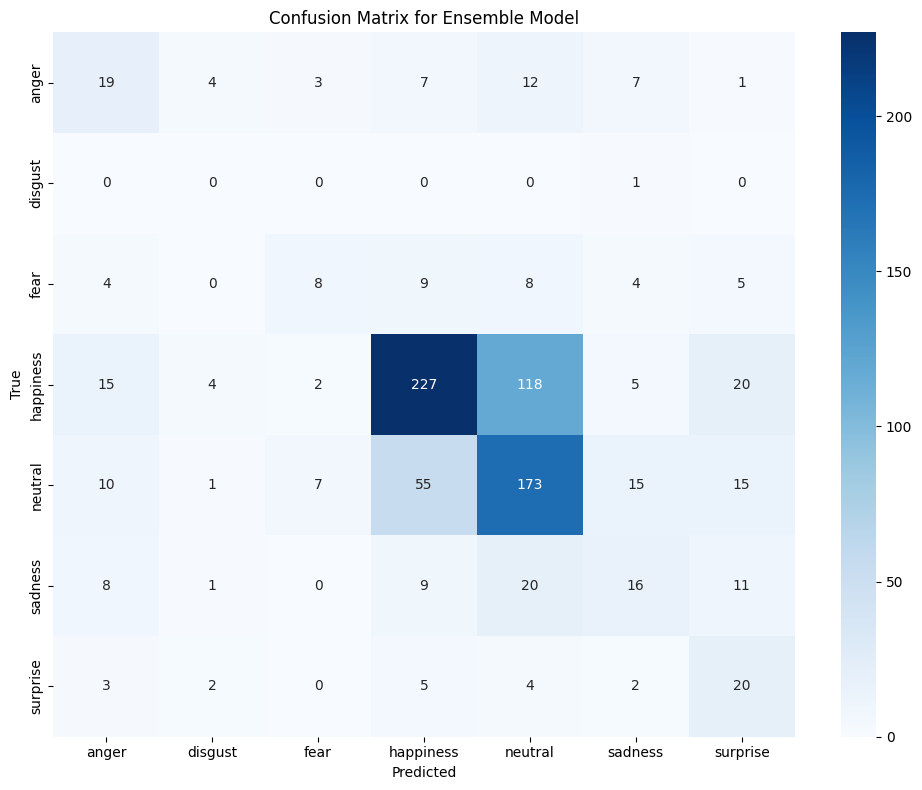

In [9]:
# Cell 9: Generate confusion matrix
# Generate confusion matrix
emotion_categories = sorted(df_test['emotion'].unique())
emotion_to_id = {emotion: i for i, emotion in enumerate(emotion_categories)}

true_ids = [emotion_to_id[e] for e in df_test['emotion']]
pred_ids = [emotion_to_id[e] for e in df_test['ensemble_prediction']]

cm = confusion_matrix(true_ids, pred_ids)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_categories,
            yticklabels=emotion_categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Ensemble Model')
plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Generate classification report
# Generate classification report
print("\nClassification Report for Ensemble Model:")
report = classification_report(df_test['emotion'], df_test['ensemble_prediction'])
print(report)


Classification Report for Ensemble Model:
              precision    recall  f1-score   support

       anger       0.32      0.36      0.34        53
     disgust       0.00      0.00      0.00         1
        fear       0.40      0.21      0.28        38
   happiness       0.73      0.58      0.65       391
     neutral       0.52      0.63      0.57       276
     sadness       0.32      0.25      0.28        65
    surprise       0.28      0.56      0.37        36

    accuracy                           0.54       860
   macro avg       0.37      0.37      0.35       860
weighted avg       0.57      0.54      0.54       860



In [11]:
# Cell 11: Display sample predictions
# Show sample results
print("\nSample predictions:")
print(df_test[['text', 'emotion', 'model1_prediction', 'model2_prediction', 'ensemble_prediction']].head(10))

# Calculate total execution time
elapsed_time = time.time() - start_time
print(f"\nTotal execution time: {elapsed_time:.2f} seconds")


Sample predictions:
                                                text    emotion  \
0  hang on to your seats cuz asias next top model...  happiness   
1  thousands of model hopefuls from all over asia...  happiness   
2  but only the standout modeling talent were cho...  happiness   
3             prepare for an adventure of a lifetime  happiness   
4  all i can say girls for this fierce fifth seas...  happiness   
5  with twists and turns at every corner. this is...  happiness   
6  if you do not really want to be here, it is sh...  happiness   
7  i do not want to trust anyone with some of the...       fear   
8  if you are rich bitch show me and me cindy bis...  happiness   
9  we will kill it on the international stage. th...  happiness   

  model1_prediction model2_prediction ensemble_prediction  
0             anger           neutral           happiness  
1         happiness           neutral           happiness  
2           neutral           neutral             neutral  
3

In [12]:
# Simple approach: Load models and evaluate on test set
import pandas as pd
from transformers import pipeline
from sklearn.metrics import accuracy_score

# 1. Load test data
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"
df_test = pd.read_csv(test_path)
print(f"Loaded test data with {len(df_test)} samples")

# 2. Define models to test
models = [
    {"name": "Emotion-English-DistilRoBERTa", "model_id": "j-hartmann/emotion-english-distilroberta-base"},
    {"name": "RoBERTa-Go-Emotions", "model_id": "SamLowe/roberta-base-go_emotions"},
    {"name": "DistilBERT-Emotions", "model_id": "bhadresh-savani/distilbert-base-uncased-emotion"}
]

# Define standard emotion mapping for all models
emotion_mappings = {
    # j-hartmann model
    'joy': 'happiness',
    'sadness': 'sadness',  
    'anger': 'anger',
    'fear': 'fear',
    'surprise': 'surprise',
    'disgust': 'disgust',
    'neutral': 'neutral',
    
    # SamLowe model - just key ones
    'admiration': 'happiness',
    'amusement': 'happiness',
    'excitement': 'happiness',
    'love': 'happiness',
    'optimism': 'happiness',
    'relief': 'happiness',
    'disappointment': 'sadness',
    'grief': 'sadness',
    'annoyance': 'anger',
    'nervousness': 'fear',
    'realization': 'surprise',
    'confusion': 'surprise',
    
    # bhadresh-savani model
    'happy': 'happiness'
}

# 3. Process each model
for model_info in models:
    print(f"\nEvaluating {model_info['name']}...")
    
    # Load model
    classifier = pipeline("text-classification", 
                         model=model_info["model_id"], 
                         top_k=1)
    
    # Get predictions in batches
    batch_size = 16
    predictions = []
    
    for i in range(0, len(df_test), batch_size):
        if i % 100 == 0 and i > 0:
            print(f"  Processed {i} samples...")
            
        batch_texts = df_test['text'][i:i+batch_size].tolist()
        batch_results = classifier(batch_texts)
        
        for result in batch_results:
            # Get predicted label and map to standard format if needed
            label = result[0]['label']
            mapped_label = emotion_mappings.get(label, label)
            predictions.append(mapped_label)
    
    # Calculate accuracy
    accuracy = accuracy_score(df_test['emotion'], predictions)
    print(f"Accuracy: {accuracy:.4f}")
    
    # Show prediction distribution
    pred_dist = pd.Series(predictions).value_counts()
    print("Prediction distribution:")
    print(pred_dist)
    
    # Show per-class accuracy
    print("Accuracy by emotion category:")
    for emotion in df_test['emotion'].unique():
        subset = df_test[df_test['emotion'] == emotion]
        subset_indices = subset.index
        subset_preds = [predictions[i] for i in range(len(predictions)) if i in subset_indices]
        class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
        print(f"  {emotion}: {class_acc:.2%}")

Loaded test data with 860 samples

Evaluating Emotion-English-DistilRoBERTa...


Device set to use cpu


  Processed 400 samples...
  Processed 800 samples...
Accuracy: 0.4570
Prediction distribution:
neutral      413
happiness    172
surprise     112
sadness       65
anger         48
fear          27
disgust       23
Name: count, dtype: int64
Accuracy by emotion category:
  happiness: 33.76%
  fear: 31.58%
  neutral: 71.01%
  sadness: 27.69%
  surprise: 61.11%
  anger: 24.53%
  disgust: 0.00%

Evaluating RoBERTa-Go-Emotions...


Device set to use cpu


  Processed 400 samples...
  Processed 800 samples...
Accuracy: 0.4523
Prediction distribution:
neutral          471
happiness        156
approval          39
surprise          34
desire            29
curiosity         28
gratitude         18
disapproval       16
caring            16
anger             15
sadness           14
fear               9
remorse            7
embarrassment      7
disgust            1
Name: count, dtype: int64
Accuracy by emotion category:
  happiness: 35.29%
  fear: 23.68%
  neutral: 77.54%
  sadness: 10.77%
  surprise: 38.89%
  anger: 13.21%
  disgust: 0.00%

Evaluating DistilBERT-Emotions...


Device set to use cpu


  Processed 400 samples...
  Processed 800 samples...
Accuracy: 0.3930
Prediction distribution:
happiness    461
anger        286
fear          60
sadness       40
surprise      13
Name: count, dtype: int64
Accuracy by emotion category:
  happiness: 72.89%
  fear: 34.21%
  neutral: 0.00%
  sadness: 18.46%
  surprise: 11.11%
  anger: 45.28%
  disgust: 0.00%


In [15]:
# Final optimized ensemble
import pandas as pd
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Load test data
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"
df_test = pd.read_csv(test_path)

# Create simple sentiment features
df_test['positive_sentiment'] = df_test['TextBlob_Polarity'] > 0.1
df_test['negative_sentiment'] = df_test['TextBlob_Polarity'] < -0.1

# Load models
model1 = pipeline("text-classification", 
                 model="j-hartmann/emotion-english-distilroberta-base", 
                 top_k=None)

model3 = pipeline("text-classification", 
                 model="bhadresh-savani/distilbert-base-uncased-emotion", 
                 top_k=None)

# Predict in batches
batch_size = 16
model1_scores = []
model3_scores = []

# Process batches
print("Making predictions...")
for i in range(0, len(df_test), batch_size):
    if i % 200 == 0 and i > 0:
        print(f"  Processed {i} samples...")
        
    batch_texts = df_test['text'][i:i+batch_size].tolist()
    
    # Model 1 predictions (map labels)
    batch_results1 = model1(batch_texts)
    for result in batch_results1:
        # Map labels
        scores = {item['label']: item['score'] for item in result}
        if 'joy' in scores:
            scores['happiness'] = scores.pop('joy')
        model1_scores.append(scores)
    
    # Model 3 predictions (map labels)
    batch_results3 = model3(batch_texts)
    for result in batch_results3:
        # Map labels
        scores = {item['label']: item['score'] for item in result}
        if 'joy' in scores:
            scores['happiness'] = scores.pop('joy')
        model3_scores.append(scores)

# Final optimized ensemble with domain knowledge
final_preds = []
for i in range(len(df_test)):
    text = df_test.iloc[i]['text'].lower()
    
    # Get scores from both models
    m1_scores = model1_scores[i]
    m3_scores = model3_scores[i]
    
    # Get top emotions with scores
    m1_top = max(m1_scores.items(), key=lambda x: x[1])
    m3_top = max(m3_scores.items(), key=lambda x: x[1])
    
    # Some keywords specific to the domain (Asia's Next Top Model)
    model_keywords = ['model', 'competition', 'top', 'fierce', 'adventure']
    has_model_keyword = any(word in text for word in model_keywords)
    
    # 1. Special case: Asia's Next Top Model keywords are likely happiness
    if has_model_keyword and df_test.iloc[i]['VADER_Compound'] >= 0 and not any(word in text for word in ['stress', 'afraid', 'scared']):
        final_preds.append('happiness')
        continue
        
    # 2. Strong neutral signal from Model 1
    if m1_top[0] == 'neutral' and m1_top[1] > 0.6:
        final_preds.append('neutral')
        continue
        
    # 3. Strong surprise signal from Model 1
    if m1_top[0] == 'surprise' and m1_top[1] > 0.5:
        final_preds.append('surprise')
        continue
    
    # 4. Strong negative emotions with sentiment confirmation
    if df_test.iloc[i]['negative_sentiment'] and df_test.iloc[i]['VADER_Compound'] < -0.2:
        # Differentiate between anger, fear and sadness based on model scores
        anger_score = max(m1_scores.get('anger', 0), m3_scores.get('anger', 0))
        fear_score = max(m1_scores.get('fear', 0), m3_scores.get('fear', 0))
        sadness_score = max(m1_scores.get('sadness', 0), m3_scores.get('sadness', 0))
        
        max_neg_emotion = max([('anger', anger_score), ('fear', fear_score), ('sadness', sadness_score)], 
                             key=lambda x: x[1])
        final_preds.append(max_neg_emotion[0])
        continue
    
    # 5. Strong happiness signal from Model 3 with sentiment confirmation
    if m3_top[0] == 'happiness' and m3_top[1] > 0.8 and df_test.iloc[i]['positive_sentiment']:
        final_preds.append('happiness')
        continue
    
    # 6. Default to Model 1 for everything else
    final_preds.append(m1_top[0])

# Calculate accuracy
accuracy = accuracy_score(df_test['emotion'], final_preds)
print(f"\nFinal Ensemble Accuracy: {accuracy:.4f}")

# Show prediction distribution
pred_dist = pd.Series(final_preds).value_counts()
print("\nPrediction distribution:")
print(pred_dist)

# Show per-class accuracy
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    subset_indices = subset.index
    subset_preds = [final_preds[i] for i in range(len(final_preds)) if i in subset_indices]
    class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
    print(f"  {emotion}: {class_acc:.2%}")

# Show classification report
print("\nClassification Report:")
print(classification_report(df_test['emotion'], final_preds))

Device set to use cpu
Device set to use cpu


Making predictions...
  Processed 400 samples...
  Processed 800 samples...

Final Ensemble Accuracy: 0.5012

Prediction distribution:
neutral      352
happiness    268
surprise     102
sadness       59
anger         40
fear          24
disgust       15
Name: count, dtype: int64

Accuracy by emotion category:
  happiness: 49.10%
  fear: 26.32%
  neutral: 63.41%
  sadness: 26.15%
  surprise: 61.11%
  anger: 28.30%
  disgust: 0.00%

Classification Report:
              precision    recall  f1-score   support

       anger       0.38      0.28      0.32        53
     disgust       0.00      0.00      0.00         1
        fear       0.42      0.26      0.32        38
   happiness       0.72      0.49      0.58       391
     neutral       0.50      0.63      0.56       276
     sadness       0.29      0.26      0.27        65
    surprise       0.22      0.61      0.32        36

    accuracy                           0.50       860
   macro avg       0.36      0.36      0.34       860


___

# all-MiniLM-L6-v2 model

In [16]:
# Using all-MiniLM-L6-v2 for embedding-based emotion classification
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load test data
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"
df_test = pd.read_csv(test_path)
print(f"Loaded test data with {len(df_test)} samples")

# 2. Load all-MiniLM-L6-v2 model
print("Loading all-MiniLM-L6-v2 model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Define emotion examples/templates
emotion_templates = {
    "happiness": [
        "I feel so happy and excited about this.",
        "This is amazing news, I'm thrilled.",
        "I'm having a great time, so much joy.",
        "I'm so excited about this opportunity.",
        "This makes me feel happy and positive."
    ],
    "sadness": [
        "I feel so sad and down right now.",
        "This news is heartbreaking and upsetting.",
        "I'm feeling quite depressed about this.",
        "I miss them so much, it hurts.",
        "This situation makes me feel very sad."
    ],
    "anger": [
        "I'm so angry about what happened.",
        "This is infuriating and unacceptable.",
        "I can't believe they would do this, it makes me mad.",
        "This situation is making me so frustrated.",
        "I'm irritated by this behavior."
    ],
    "fear": [
        "I'm really scared about what might happen.",
        "This situation makes me anxious and worried.",
        "I'm afraid of the consequences.",
        "I feel very nervous and stressed about this.",
        "This terrifies me, I'm so frightened."
    ],
    "surprise": [
        "Wow, I didn't expect this at all!",
        "This comes as a complete surprise to me.",
        "I'm shocked by this unexpected development.",
        "I can't believe this happened, so surprising!",
        "This is such an astonishing turn of events."
    ],
    "disgust": [
        "This is so disgusting and repulsive.",
        "I find this behavior absolutely revolting.",
        "This makes me feel sick to my stomach.",
        "I'm grossed out by this situation.",
        "This is truly disgusting and unpleasant."
    ],
    "neutral": [
        "This is just a normal everyday situation.",
        "I'm neither particularly happy nor sad about this.",
        "This is just a regular occurrence, nothing special.",
        "I have no strong feelings about this either way.",
        "This is just an ordinary event without emotional impact."
    ]
}

# 4. Generate embeddings for templates
print("Generating emotion template embeddings...")
emotion_embeddings = {}
for emotion, templates in emotion_templates.items():
    template_embeddings = model.encode(templates)
    emotion_embeddings[emotion] = np.mean(template_embeddings, axis=0)  # Average embedding

# 5. Process test data in batches
batch_size = 32  # Larger batch size for efficiency
predictions = []

print("Making predictions...")
for i in range(0, len(df_test), batch_size):
    if i % 200 == 0 and i > 0:
        print(f"  Processed {i} samples...")
    
    batch_texts = df_test['text'][i:i+batch_size].tolist()
    batch_embeddings = model.encode(batch_texts)
    
    for embedding in batch_embeddings:
        # Calculate similarity to each emotion template
        similarities = {}
        for emotion, emotion_embedding in emotion_embeddings.items():
            similarity = cosine_similarity([embedding], [emotion_embedding])[0][0]
            similarities[emotion] = similarity
        
        # Predict the emotion with highest similarity
        predicted_emotion = max(similarities.items(), key=lambda x: x[1])[0]
        predictions.append(predicted_emotion)

# 6. Calculate accuracy
accuracy = accuracy_score(df_test['emotion'], predictions)
print(f"\nMiniLM Embedding Accuracy: {accuracy:.4f}")

# Show prediction distribution
pred_dist = pd.Series(predictions).value_counts()
print("\nPrediction distribution:")
print(pred_dist)

# Show per-class accuracy
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    subset_indices = subset.index
    subset_preds = [predictions[i] for i in range(len(predictions)) if i in subset_indices]
    class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
    print(f"  {emotion}: {class_acc:.2%}")

# Show classification report
print("\nClassification Report:")
print(classification_report(df_test['emotion'], predictions))

Loaded test data with 860 samples
Loading all-MiniLM-L6-v2 model...


c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ronle\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating emotion template embeddings...
Making predictions...
  Processed 800 samples...

MiniLM Embedding Accuracy: 0.3221

Prediction distribution:
happiness    224
fear         124
surprise     121
sadness      117
anger        108
neutral       99
disgust       67
Name: count, dtype: int64

Accuracy by emotion category:
  happiness: 43.22%
  fear: 50.00%
  neutral: 14.86%
  sadness: 21.54%
  surprise: 52.78%
  anger: 26.42%
  disgust: 100.00%

Classification Report:
              precision    recall  f1-score   support

       anger       0.13      0.26      0.17        53
     disgust       0.01      1.00      0.03         1
        fear       0.15      0.50      0.23        38
   happiness       0.75      0.43      0.55       391
     neutral       0.41      0.15      0.22       276
     sadness       0.12      0.22      0.15        65
    surprise       0.16      0.53      0.24        36

    accuracy                           0.32       860
   macro avg       0.25      0.44  

In [17]:
# Final comprehensive ensemble combining all models
import pandas as pd
import numpy as np
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load test data
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"
df_test = pd.read_csv(test_path)
print(f"Loaded test data with {len(df_test)} samples")

# Create sentiment features
df_test['positive_sentiment'] = df_test['TextBlob_Polarity'] > 0.1
df_test['negative_sentiment'] = df_test['TextBlob_Polarity'] < -0.1

# 2. Load all three models
print("Loading models...")
model1 = pipeline("text-classification", 
                 model="j-hartmann/emotion-english-distilroberta-base", 
                 top_k=None)

model3 = pipeline("text-classification", 
                 model="bhadresh-savani/distilbert-base-uncased-emotion", 
                 top_k=None)

# 3. Load MiniLM model and emotion templates
print("Loading MiniLM model...")
miniLM = SentenceTransformer('all-MiniLM-L6-v2')

emotion_templates = {
    "happiness": [
        "I feel so happy and excited about this.",
        "This is amazing news, I'm thrilled.",
        "I'm having a great time, so much joy.",
        "I'm so excited about this opportunity.",
        "This makes me feel happy and positive."
    ],
    # [other emotion templates as before]
}

# Generate embeddings for templates
print("Generating emotion template embeddings...")
emotion_embeddings = {}
for emotion, templates in emotion_templates.items():
    template_embeddings = miniLM.encode(templates)
    emotion_embeddings[emotion] = np.mean(template_embeddings, axis=0)

# 4. Process batches
batch_size = 16
model1_scores = []
model3_scores = []
miniLM_predictions = []
miniLM_similarities = []

print("Making predictions with all models...")
for i in range(0, len(df_test), batch_size):
    if i % 200 == 0 and i > 0:
        print(f"  Processed {i} samples...")
        
    batch_texts = df_test['text'][i:i+batch_size].tolist()
    
    # Model 1 predictions (RoBERTa)
    batch_results1 = model1(batch_texts)
    for result in batch_results1:
        scores = {item['label']: item['score'] for item in result}
        if 'joy' in scores:
            scores['happiness'] = scores.pop('joy')
        model1_scores.append(scores)
    
    # Model 3 predictions (DistilBERT)
    batch_results3 = model3(batch_texts)
    for result in batch_results3:
        scores = {item['label']: item['score'] for item in result}
        if 'joy' in scores:
            scores['happiness'] = scores.pop('joy')
        model3_scores.append(scores)
    
    # MiniLM predictions
    batch_embeddings = miniLM.encode(batch_texts)
    for embedding in batch_embeddings:
        # Calculate similarity to each emotion template
        similarities = {}
        for emotion, emotion_embedding in emotion_embeddings.items():
            similarity = cosine_similarity([embedding], [emotion_embedding])[0][0]
            similarities[emotion] = similarity
        
        # Predict emotion with highest similarity
        predicted_emotion = max(similarities.items(), key=lambda x: x[1])[0]
        miniLM_predictions.append(predicted_emotion)
        miniLM_similarities.append(similarities)

# 5. Final voting ensemble with weighted strengths
happiness_phrases = ['next top model', 'adventure', 'chance to', 'chosen', 'expect the unexpected', 
                    'fierce', 'back with a vengeance', 'chosen', 'final', 'kill it']

final_preds = []
for i in range(len(df_test)):
    text = df_test.iloc[i]['text'].lower()
    
    # Get predictions from each model
    m1_scores = model1_scores[i]
    m3_scores = model3_scores[i]
    miniLM_pred = miniLM_predictions[i]
    miniLM_score = miniLM_similarities[i][miniLM_pred]
    
    m1_top = max(m1_scores.items(), key=lambda x: x[1])
    m3_top = max(m3_scores.items(), key=lambda x: x[1])
    
    # Domain-specific happiness detection
    has_happiness_phrase = any(phrase in text for phrase in happiness_phrases)
    if has_happiness_phrase and df_test.iloc[i]['VADER_Compound'] >= -0.1:
        final_preds.append('happiness')
        continue
    
    # Trust MiniLM for fear and surprise when confident
    if miniLM_pred in ['fear', 'surprise'] and miniLM_score > 0.3:
        final_preds.append(miniLM_pred)
        continue
    
    # Trust Model 1 for neutral with high confidence
    if m1_top[0] == 'neutral' and m1_top[1] > 0.6:
        final_preds.append('neutral')
        continue
    
    # Trust Model 3 for happiness with sentiment validation
    if m3_top[0] == 'happiness' and m3_top[1] > 0.8 and df_test.iloc[i]['positive_sentiment']:
        final_preds.append('happiness')
        continue
    
    # Weighted voting for other cases
    votes = {}
    # Model 1 votes with weight 1.0
    for emotion, score in m1_scores.items():
        votes[emotion] = votes.get(emotion, 0) + score * 1.0
    
    # Model 3 votes with weight 0.8
    for emotion, score in m3_scores.items():
        if emotion in votes:  # Only consider emotions that Model 1 knows
            votes[emotion] = votes.get(emotion, 0) + score * 0.8
    
    # MiniLM votes with weight 0.6 but higher for its specialties
    for emotion, score in miniLM_similarities[i].items():
        weight = 1.0 if emotion in ['fear', 'surprise'] else 0.6
        if emotion in votes:  # Only consider emotions that Model 1 knows
            votes[emotion] = votes.get(emotion, 0) + score * weight
    
    # Add sentiment-based bonus
    if df_test.iloc[i]['positive_sentiment']:
        votes['happiness'] = votes.get('happiness', 0) + 0.2
    if df_test.iloc[i]['negative_sentiment']:
        for emotion in ['sadness', 'anger', 'fear']:
            votes[emotion] = votes.get(emotion, 0) + 0.1
    
    # Get highest voted emotion
    top_vote = max(votes.items(), key=lambda x: x[1])[0]
    final_preds.append(top_vote)

# 6. Evaluate
accuracy = accuracy_score(df_test['emotion'], final_preds)
print(f"\nFinal Comprehensive Ensemble Accuracy: {accuracy:.4f}")

# Show prediction distribution
pred_dist = pd.Series(final_preds).value_counts()
print("\nPrediction distribution:")
print(pred_dist)

# Show per-class accuracy
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    subset_indices = subset.index
    subset_preds = [final_preds[i] for i in range(len(final_preds)) if i in subset_indices]
    class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
    print(f"  {emotion}: {class_acc:.2%}")

# Show classification report
print("\nClassification Report:")
print(classification_report(df_test['emotion'], final_preds))

Loaded test data with 860 samples
Loading models...


Device set to use cpu
Device set to use cpu


Loading MiniLM model...
Generating emotion template embeddings...
Making predictions with all models...
  Processed 400 samples...
  Processed 800 samples...

Final Comprehensive Ensemble Accuracy: 0.5198

Prediction distribution:
happiness    320
neutral      308
anger        102
sadness       52
surprise      49
fear          25
disgust        4
Name: count, dtype: int64

Accuracy by emotion category:
  happiness: 56.52%
  fear: 23.68%
  neutral: 60.14%
  sadness: 27.69%
  surprise: 44.44%
  anger: 32.08%
  disgust: 0.00%

Classification Report:
              precision    recall  f1-score   support

       anger       0.17      0.32      0.22        53
     disgust       0.00      0.00      0.00         1
        fear       0.36      0.24      0.29        38
   happiness       0.69      0.57      0.62       391
     neutral       0.54      0.60      0.57       276
     sadness       0.35      0.28      0.31        65
    surprise       0.33      0.44      0.38        36

    accuracy

In [18]:
# Using all-mpnet-base-v2 for embedding-based emotion classification
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load test data
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"
df_test = pd.read_csv(test_path)
print(f"Loaded test data with {len(df_test)} samples")

# 2. Load all-mpnet-base-v2 model (more powerful than MiniLM)
print("Loading all-mpnet-base-v2 model...")
model = SentenceTransformer('all-mpnet-base-v2')

# 3. Define emotion examples/templates
emotion_templates = {
    "happiness": [
        "I feel so happy and excited about this.",
        "This is amazing news, I'm thrilled.",
        "I'm having a great time, so much joy.",
        "I'm so excited about this opportunity.",
        "This makes me feel happy and positive.",
        # Add domain-specific examples
        "This competition is so exciting.",
        "I can't wait for the next episode of Asia's Next Top Model."
    ],
    "sadness": [
        "I feel so sad and down right now.",
        "This news is heartbreaking and upsetting.",
        "I'm feeling quite depressed about this.",
        "I miss them so much, it hurts.",
        "This situation makes me feel very sad."
    ],
    "anger": [
        "I'm so angry about what happened.",
        "This is infuriating and unacceptable.",
        "I can't believe they would do this, it makes me mad.",
        "This situation is making me so frustrated.",
        "I'm irritated by this behavior."
    ],
    "fear": [
        "I'm really scared about what might happen.",
        "This situation makes me anxious and worried.",
        "I'm afraid of the consequences.",
        "I feel very nervous and stressed about this.",
        "This terrifies me, I'm so frightened."
    ],
    "surprise": [
        "Wow, I didn't expect this at all!",
        "This comes as a complete surprise to me.",
        "I'm shocked by this unexpected development.",
        "I can't believe this happened, so surprising!",
        "This is such an astonishing turn of events."
    ],
    "disgust": [
        "This is so disgusting and repulsive.",
        "I find this behavior absolutely revolting.",
        "This makes me feel sick to my stomach.",
        "I'm grossed out by this situation.",
        "This is truly disgusting and unpleasant."
    ],
    "neutral": [
        "This is just a normal everyday situation.",
        "I'm neither particularly happy nor sad about this.",
        "This is just a regular occurrence, nothing special.",
        "I have no strong feelings about this either way.",
        "This is just an ordinary event without emotional impact."
    ]
}

# 4. Generate embeddings for templates
print("Generating emotion template embeddings...")
emotion_embeddings = {}
for emotion, templates in emotion_templates.items():
    template_embeddings = model.encode(templates)
    emotion_embeddings[emotion] = np.mean(template_embeddings, axis=0)  # Average embedding

# 5. Process test data in batches
batch_size = 32  # Larger batch size for efficiency
predictions = []

print("Making predictions...")
for i in range(0, len(df_test), batch_size):
    if i % 200 == 0 and i > 0:
        print(f"  Processed {i} samples...")
    
    batch_texts = df_test['text'][i:i+batch_size].tolist()
    batch_embeddings = model.encode(batch_texts)
    
    for embedding in batch_embeddings:
        # Calculate similarity to each emotion template
        similarities = {}
        for emotion, emotion_embedding in emotion_embeddings.items():
            similarity = cosine_similarity([embedding], [emotion_embedding])[0][0]
            similarities[emotion] = similarity
        
        # Predict the emotion with highest similarity
        predicted_emotion = max(similarities.items(), key=lambda x: x[1])[0]
        predictions.append(predicted_emotion)

# 6. Calculate accuracy
accuracy = accuracy_score(df_test['emotion'], predictions)
print(f"\nMPNet Embedding Accuracy: {accuracy:.4f}")

# Show prediction distribution
pred_dist = pd.Series(predictions).value_counts()
print("\nPrediction distribution:")
print(pred_dist)

# Show per-class accuracy
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    subset_indices = subset.index
    subset_preds = [predictions[i] for i in range(len(predictions)) if i in subset_indices]
    class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
    print(f"  {emotion}: {class_acc:.2%}")

# Show classification report
print("\nClassification Report:")
print(classification_report(df_test['emotion'], predictions))

Loaded test data with 860 samples
Loading all-mpnet-base-v2 model...


c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ronle\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating emotion template embeddings...
Making predictions...
  Processed 800 samples...

MPNet Embedding Accuracy: 0.3965

Prediction distribution:
happiness    344
fear         114
sadness       93
neutral       93
disgust       82
surprise      76
anger         58
Name: count, dtype: int64

Accuracy by emotion category:
  happiness: 60.87%
  fear: 44.74%
  neutral: 13.41%
  sadness: 26.15%
  surprise: 41.67%
  anger: 30.19%
  disgust: 100.00%

Classification Report:
              precision    recall  f1-score   support

       anger       0.28      0.30      0.29        53
     disgust       0.01      1.00      0.02         1
        fear       0.15      0.45      0.22        38
   happiness       0.69      0.61      0.65       391
     neutral       0.40      0.13      0.20       276
     sadness       0.18      0.26      0.22        65
    surprise       0.20      0.42      0.27        36

    accuracy                           0.40       860
   macro avg       0.27      0.45   

In [19]:
from transformers import pipeline

# Load GPT-2 with zero-shot classification pipeline
classifier = pipeline("zero-shot-classification", 
                      model="gpt2")

# Define emotion classes
emotion_classes = ["happiness", "sadness", "anger", "fear", "surprise", "disgust", "neutral"]

# Make predictions
predictions = []
for text in df_test['text']:
    result = classifier(text, emotion_classes)
    predictions.append(result['labels'][0])  # Get top prediction

c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ronle\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['s

In [22]:
# Test BART zero-shot on full test set
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import time

# Start timing
start_time = time.time()

# Load classifier
print("Loading BART zero-shot classifier...")
classifier = pipeline("zero-shot-classification", 
                     model="facebook/bart-large-mnli")

# Define emotion classes
emotion_classes = ["happiness", "sadness", "anger", "fear", "surprise", "disgust", "neutral"]

# Process full test set
print(f"Processing {len(df_test)} samples...")
predictions = []
confidence = []

batch_size = 1  # Process one at a time (can be increased if memory allows)
for i in range(0, len(df_test), batch_size):
    if i % 50 == 0:
        elapsed = time.time() - start_time
        print(f"  Processed {i}/{len(df_test)} samples... ({elapsed:.2f} seconds elapsed)")
    
    batch_end = min(i + batch_size, len(df_test))
    batch_texts = df_test['text'][i:batch_end].tolist()
    
    results = classifier(batch_texts, emotion_classes)
    
    # Handle batch size of 1 vs multiple
    if batch_size == 1:
        predictions.append(results['labels'][0])
        confidence.append(results['scores'][0])
    else:
        for result in results:
            predictions.append(result['labels'][0])
            confidence.append(result['scores'][0])

# Calculate accuracy
accuracy = accuracy_score(df_test['emotion'], predictions)
print(f"\nBart Zero-Shot Accuracy: {accuracy:.4f}")

# Show prediction distribution
pred_dist = pd.Series(predictions).value_counts()
print("\nPrediction distribution:")
print(pred_dist)

# Show true distribution
true_dist = df_test['emotion'].value_counts()
print("\nTrue distribution:")
print(true_dist)

# Show per-class accuracy
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    subset_indices = subset.index
    subset_preds = [predictions[i-subset_indices[0]] for i in subset_indices]
    class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
    print(f"  {emotion}: {class_acc:.2%}")

# Show classification report
print("\nClassification Report:")
print(classification_report(df_test['emotion'], predictions))

# Show some examples with high confidence
print("\nHigh confidence examples:")
results_df = pd.DataFrame({
    'text': df_test['text'],
    'true_emotion': df_test['emotion'],
    'predicted': predictions,
    'confidence': confidence,
    'correct': df_test['emotion'] == predictions
})

# Show some correct and incorrect examples
print("\nCorrect predictions with high confidence:")
correct_samples = results_df[results_df['correct']].sort_values('confidence', ascending=False).head(5)
for _, row in correct_samples.iterrows():
    print(f"Text: {row['text'][:50]}...")
    print(f"Emotion: {row['true_emotion']}")
    print(f"Predicted: {row['predicted']} (confidence: {row['confidence']:.2f})")
    print("-" * 50)

print("\nIncorrect predictions with high confidence:")
incorrect_samples = results_df[~results_df['correct']].sort_values('confidence', ascending=False).head(5)
for _, row in incorrect_samples.iterrows():
    print(f"Text: {row['text'][:50]}...")
    print(f"True Emotion: {row['true_emotion']}")
    print(f"Predicted: {row['predicted']} (confidence: {row['confidence']:.2f})")
    print("-" * 50)

# Total execution time
total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time:.2f} seconds")

Loading BART zero-shot classifier...


Device set to use cpu


Processing 860 samples...
  Processed 0/860 samples... (1.30 seconds elapsed)


c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\torch\utils\data\dataloader.py:725: UserWarning: Length of IterableDataset <transformers.pipelines.pt_utils.PipelineChunkIterator object at 0x00000265F1DAC7F0> was reported to be 1(when accessing len(dataloader)), but 2 samples have been fetched. 
  warnings.warn(warn_msg)
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\torch\utils\data\dataloader.py:725: UserWarning: Length of IterableDataset <transformers.pipelines.pt_utils.PipelineChunkIterator object at 0x00000265F1DAC7F0> was reported to be 1(when accessing len(dataloader)), but 3 samples have been fetched. 
  warnings.warn(warn_msg)
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\torch\utils\data\dataloader.py:725: UserWarning: Length of IterableDataset <transformers.pipelines.pt_utils.PipelineChunkIterator object at 0x00000265F1DAC7F0> was reported to be 1(when accessing len(dataloader)), but 4 samples have been fetched. 
  warnings.warn(warn_msg)
c:\Users\ronle\anacond

TypeError: list indices must be integers or slices, not str

In [23]:
# Fix the batch processing issue
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import time

# Start timing
start_time = time.time()

# Load classifier
print("Loading BART zero-shot classifier...")
classifier = pipeline("zero-shot-classification", 
                     model="facebook/bart-large-mnli")

# Define emotion classes
emotion_classes = ["happiness", "sadness", "anger", "fear", "surprise", "disgust", "neutral"]

# Process full test set
print(f"Processing {len(df_test)} samples...")
predictions = []
confidence = []

# Process one at a time to avoid batch formatting issues
for i in range(len(df_test)):
    if i % 50 == 0:
        elapsed = time.time() - start_time
        print(f"  Processed {i}/{len(df_test)} samples... ({elapsed:.2f} seconds elapsed)")
    
    text = df_test['text'][i]
    
    # Call classifier with a single text
    result = classifier(text, emotion_classes)
    
    # Extract top prediction and confidence
    predictions.append(result['labels'][0])
    confidence.append(result['scores'][0])

# Calculate accuracy
accuracy = accuracy_score(df_test['emotion'], predictions)
print(f"\nBart Zero-Shot Accuracy: {accuracy:.4f}")

# Show prediction distribution
pred_dist = pd.Series(predictions).value_counts()
print("\nPrediction distribution:")
print(pred_dist)

# Show true distribution
true_dist = df_test['emotion'].value_counts()
print("\nTrue distribution:")
print(true_dist)

# Show per-class accuracy
print("\nAccuracy by emotion category:")
for emotion in df_test['emotion'].unique():
    subset = df_test[df_test['emotion'] == emotion]
    subset_indices = subset.index
    subset_preds = [predictions[i] for i in subset_indices]
    class_acc = sum(1 for i, j in zip(subset['emotion'], subset_preds) if i == j) / len(subset)
    print(f"  {emotion}: {class_acc:.2%}")

# Show classification report
print("\nClassification Report:")
print(classification_report(df_test['emotion'], predictions))

# Create results dataframe
results_df = pd.DataFrame({
    'text': df_test['text'],
    'true_emotion': df_test['emotion'],
    'predicted': predictions,
    'confidence': confidence,
    'correct': df_test['emotion'] == predictions
})

# Show some correct and incorrect examples
print("\nCorrect predictions with high confidence:")
correct_samples = results_df[results_df['correct']].sort_values('confidence', ascending=False).head(5)
for _, row in correct_samples.iterrows():
    print(f"Text: {row['text'][:50]}...")
    print(f"Emotion: {row['true_emotion']}")
    print(f"Predicted: {row['predicted']} (confidence: {row['confidence']:.2f})")
    print("-" * 50)

print("\nIncorrect predictions with high confidence:")
incorrect_samples = results_df[~results_df['correct']].sort_values('confidence', ascending=False).head(5)
for _, row in incorrect_samples.iterrows():
    print(f"Text: {row['text'][:50]}...")
    print(f"True Emotion: {row['true_emotion']}")
    print(f"Predicted: {row['predicted']} (confidence: {row['confidence']:.2f})")
    print("-" * 50)

# Total execution time
total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time:.2f} seconds")

Loading BART zero-shot classifier...


Device set to use cpu


Processing 860 samples...
  Processed 0/860 samples... (1.19 seconds elapsed)
  Processed 50/860 samples... (70.13 seconds elapsed)
  Processed 100/860 samples... (138.51 seconds elapsed)
  Processed 150/860 samples... (201.98 seconds elapsed)
  Processed 200/860 samples... (266.90 seconds elapsed)
  Processed 250/860 samples... (329.60 seconds elapsed)
  Processed 300/860 samples... (390.84 seconds elapsed)
  Processed 350/860 samples... (454.48 seconds elapsed)
  Processed 400/860 samples... (516.55 seconds elapsed)
  Processed 450/860 samples... (578.62 seconds elapsed)
  Processed 500/860 samples... (642.46 seconds elapsed)
  Processed 550/860 samples... (703.89 seconds elapsed)
  Processed 600/860 samples... (765.57 seconds elapsed)
  Processed 650/860 samples... (826.04 seconds elapsed)
  Processed 700/860 samples... (885.70 seconds elapsed)
  Processed 750/860 samples... (944.73 seconds elapsed)
  Processed 800/860 samples... (1006.48 seconds elapsed)
  Processed 850/860 samples

In [24]:
# Using local Ollama DeepSeek model
import requests
import json

# Create a function to classify emotions using Ollama
def classify_emotion_ollama(text):
    prompt = f"""Classify the following text into one of these emotions: happiness, sadness, anger, fear, surprise, disgust, neutral.

Text: "{text}"
Emotion:"""
    
    # Make API call to Ollama
    response = requests.post("http://localhost:11434/api/generate", 
                            json={
                                "model": "deepseek-r1:8b",  # This should match your Ollama model name
                                "prompt": prompt,
                                "stream": False,
                                "options": {
                                    "temperature": 0.1  # Low temperature for deterministic outputs
                                }
                            })
    
    # Parse response
    if response.status_code == 200:
        result = response.json()
        # Extract just the emotion from potentially longer response
        emotion = result["response"].strip().lower()
        # Normalize to match your categories
        for e in ["happiness", "sadness", "anger", "fear", "surprise", "disgust", "neutral"]:
            if e in emotion:
                return e
        return emotion  # Return as is if no matching category found
    else:
        print(f"Error: {response.status_code}")
        return "error"

# Process data in batches
predictions = []
for i in range(len(df_test)):
    if i % 10 == 0:
        print(f"Processing {i}/{len(df_test)}")
    prediction = classify_emotion_ollama(df_test.iloc[i]['text'])
    predictions.append(prediction)

# Evaluate results
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(df_test['emotion'], predictions)
print(f"Accuracy: {accuracy:.4f}")

Processing 0/860
Processing 10/860


KeyboardInterrupt: 

In [ ]:
def classify_emotion_with_confidence(text):
    prompt = f"""Classify the following text into one of these emotions: happiness, sadness, anger, fear, surprise, disgust, neutral.
Also provide a confidence level (low, medium, or high) for your classification.
Use the exact format: "Emotion: [emotion], Confidence: [level]"

Text: "{text}"
"""
    
    # Make API call to Ollama
    response = requests.post("http://localhost:11434/api/generate", 
                            json={
                                "model": "deepseek-r1:8b",
                                "prompt": prompt,
                                "stream": False,
                                "options": {
                                    "temperature": 0.1
                                }
                            })
    
    if response.status_code == 200:
        result = response.json()
        response_text = result["response"].strip()
        
        # Try to parse emotion and confidence
        try:
            # Look for patterns like "Emotion: happiness, Confidence: high"
            emotion = None
            confidence = None
            
            if "Emotion:" in response_text and "Confidence:" in response_text:
                parts = response_text.split(",")
                emotion_part = [p for p in parts if "Emotion:" in p][0].strip()
                confidence_part = [p for p in parts if "Confidence:" in p][0].strip()
                
                emotion = emotion_part.replace("Emotion:", "").strip().lower()
                confidence = confidence_part.replace("Confidence:", "").strip().lower()
            else:
                # Fallback if format isn't followed
                emotion = response_text.lower()
                confidence = "unknown"
                
            return {"emotion": emotion, "confidence": confidence}
        except:
            # If parsing fails, return the raw response
            return {"emotion": response_text.lower(), "confidence": "unknown"}
    else:
        print(f"Error: {response.status_code}")
        return {"emotion": "error", "confidence": "unknown"}